In [ ]:
#IMPORT LIBRARIES
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

In [ ]:
#Load Dataset
df = pd.read_csv(r"C:\Users\aksha\Downloads\speech_therapy_dataset.csv")

In [ ]:
#View Dataset
df.head()

,Child_ID,Age,Gender,Speech_Error,Severity,Sessions_Attended,Practice_Minutes_Per_Day,Parent_Support,Pronunciation_Score,Improvement,Recommended_Exercise
0,1001,5,Male,TH,Low,10,45,Low,98,High,TH_Sound_Practice
1,1002,4,Male,R,Low,8,45,Medium,98,High,R_Sound_Practice
2,1003,8,Male,S,Medium,7,20,High,55,Medium,S_Sound_Practice
3,1004,5,Male,L,Low,13,5,High,61,Medium,L_Sound_Practice
4,1005,10,Male,General,Low,13,10,Low,84,High,General_Pronunciation


In [ ]:
#Dataset Information
print(df.shape)

print()

print(df.columns)

print()

df.info()

(1000, 11)

Index(['Child_ID', 'Age', 'Gender', 'Speech_Error', 'Severity',
       'Sessions_Attended', 'Practice_Minutes_Per_Day', 'Parent_Support',
       'Pronunciation_Score', 'Improvement', 'Recommended_Exercise'],
      dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Child_ID                  1000 non-null   int64
 1   Age                       1000 non-null   int64
 2   Gender                    1000 non-null   str  
 3   Speech_Error              1000 non-null   str  
 4   Severity                  1000 non-null   str  
 5   Sessions_Attended         1000 non-null   int64
 6   Practice_Minutes_Per_Day  1000 non-null   int64
 7   Parent_Support            1000 non-null   str  
 8   Pronunciation_Score       1000 non-null   int64
 9   Improvement               1000 non-null   str  
 10  Recommended_Exercise    

In [ ]:
#Statistical Summary
df.describe()

,Child_ID,Age,Sessions_Attended,Practice_Minutes_Per_Day,Pronunciation_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1500.500000,8.025000,7.828000,25.110000,66.276000
std,288.819436,2.533139,3.244525,12.866758,18.767633
min,1001.000000,4.000000,2.000000,5.000000,11.000000
25%,1250.750000,6.000000,6.000000,15.000000,52.000000
50%,1500.500000,8.000000,8.000000,25.000000,67.000000
75%,1750.250000,10.000000,10.000000,35.000000,80.000000
max,2000.000000,12.000000,15.000000,45.000000,98.000000


In [ ]:
#Missing Values
df.isnull().sum()

Child_ID                    0
Age                         0
Gender                      0
Speech_Error                0
Severity                    0
Sessions_Attended           0
Practice_Minutes_Per_Day    0
Parent_Support              0
Pronunciation_Score         0
Improvement                 0
Recommended_Exercise        0
dtype: int64

In [ ]:
#Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [ ]:
#Remove Duplicates
df = df.drop_duplicates()

In [ ]:
#Unique Values
for col in df.columns:
    print("="*40)
    print(col)
    print(df[col].unique())

Child_ID
[1001 1002 1003 1004 1005 1006 1007 1008 1009 1010 1011 1012 1013 1014
 1015 1016 1017 1018 1019 1020 1021 1022 1023 1024 1025 1026 1027 1028
 1029 1030 1031 1032 1033 1034 1035 1036 1037 1038 1039 1040 1041 1042
 1043 1044 1045 1046 1047 1048 1049 1050 1051 1052 1053 1054 1055 1056
 1057 1058 1059 1060 1061 1062 1063 1064 1065 1066 1067 1068 1069 1070
 1071 1072 1073 1074 1075 1076 1077 1078 1079 1080 1081 1082 1083 1084
 1085 1086 1087 1088 1089 1090 1091 1092 1093 1094 1095 1096 1097 1098
 1099 1100 1101 1102 1103 1104 1105 1106 1107 1108 1109 1110 1111 1112
 1113 1114 1115 1116 1117 1118 1119 1120 1121 1122 1123 1124 1125 1126
 1127 1128 1129 1130 1131 1132 1133 1134 1135 1136 1137 1138 1139 1140
 1141 1142 1143 1144 1145 1146 1147 1148 1149 1150 1151 1152 1153 1154
 1155 1156 1157 1158 1159 1160 1161 1162 1163 1164 1165 1166 1167 1168
 1169 1170 1171 1172 1173 1174 1175 1176 1177 1178 1179 1180 1181 1182
 1183 1184 1185 1186 1187 1188 1189 1190 1191 1192 1193 1194 1195 11

In [ ]:
#Value Counts
categorical = [
    "Gender",
    "Speech_Error",
    "Severity",
    "Parent_Support",
    "Improvement",
    "Recommended_Exercise"
]

for col in categorical:
    print("\n")
    print(col)
    print(df[col].value_counts())



Gender
Gender
Female    520
Male      480
Name: count, dtype: int64


Speech_Error
Speech_Error
L          224
R          211
General    204
TH         185
S          176
Name: count, dtype: int64


Severity
Severity
Medium    395
High      303
Low       302
Name: count, dtype: int64


Parent_Support
Parent_Support
Medium    384
High      345
Low       271
Name: count, dtype: int64


Improvement
Improvement
High      442
Medium    359
Low       199
Name: count, dtype: int64


Recommended_Exercise
Recommended_Exercise
L_Sound_Practice         224
R_Sound_Practice         211
General_Pronunciation    204
TH_Sound_Practice        185
S_Sound_Practice         176
Name: count, dtype: int64


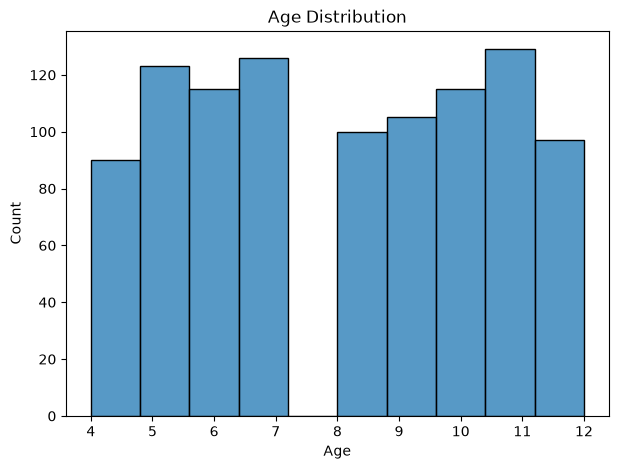

In [ ]:
#EDA Graphs
plt.figure(figsize=(7,5))
sns.histplot(df["Age"], bins=10)
plt.title("Age Distribution")
plt.show()

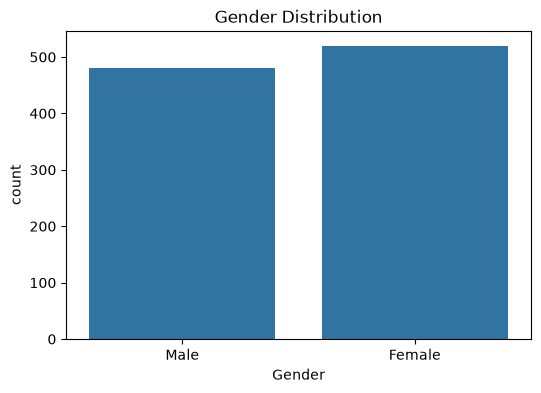

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

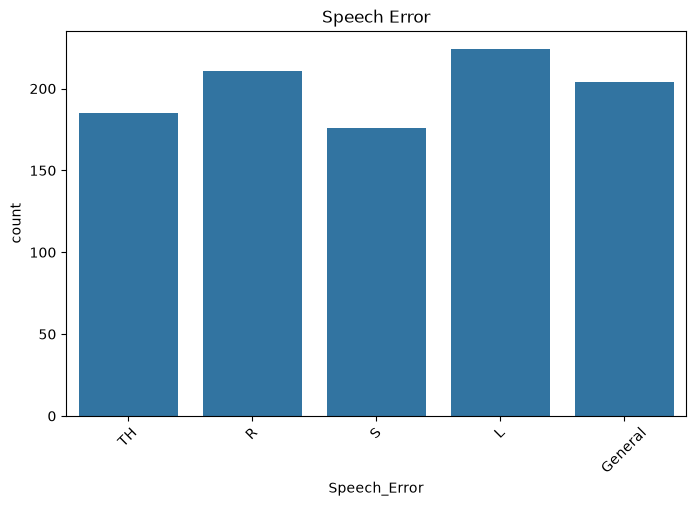

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x="Speech_Error", data=df)
plt.title("Speech Error")
plt.xticks(rotation=45)
plt.show()

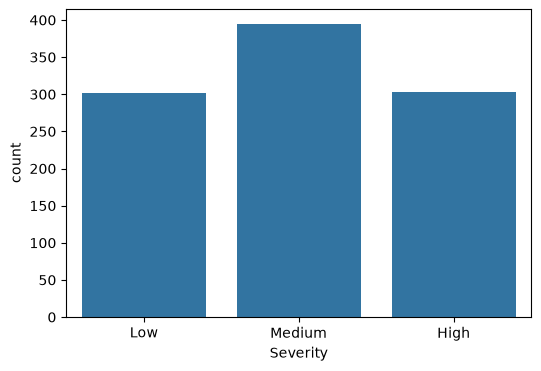

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x="Severity", data=df)
plt.show()

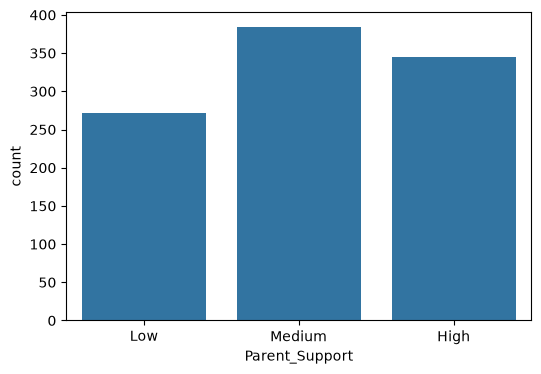

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x="Parent_Support", data=df)
plt.show()

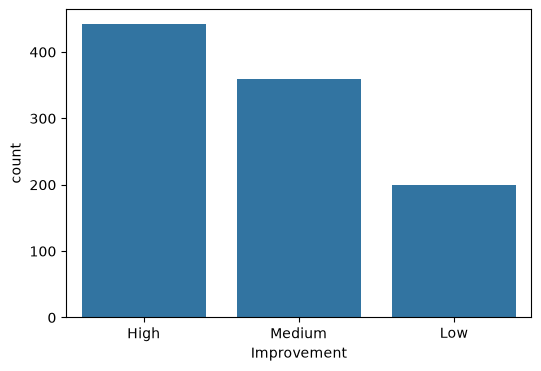

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x="Improvement", data=df)
plt.show()

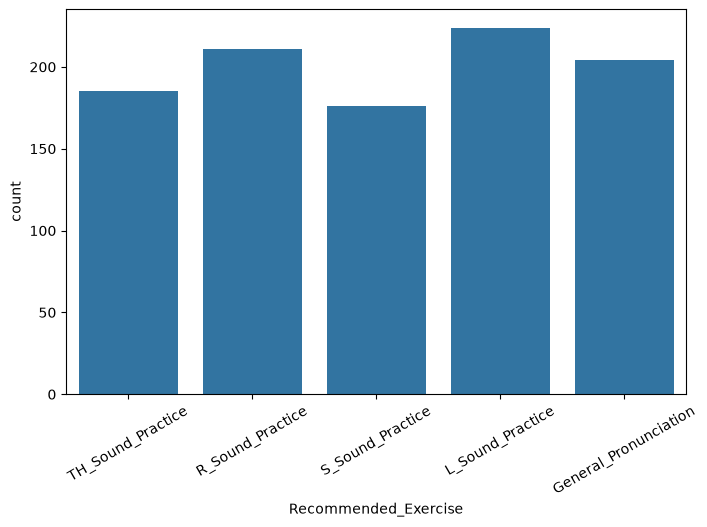

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x="Recommended_Exercise", data=df)
plt.xticks(rotation=30)
plt.show()

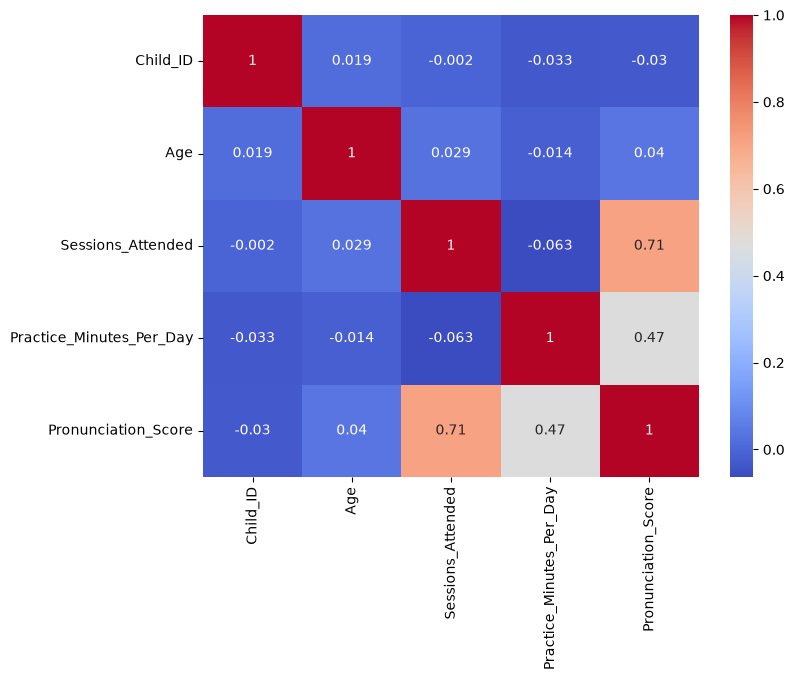

In [20]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [ ]:
#Features and Target
X = df.drop(
    columns=[
        "Child_ID",
        "Recommended_Exercise"
    ]
)

y = df["Recommended_Exercise"]

In [ ]:
#Encode Features
encoder = LabelEncoder()

cat_cols = [
    "Gender",
    "Speech_Error",
    "Severity",
    "Parent_Support",
    "Improvement"
]

for col in cat_cols:
    X[col] = encoder.fit_transform(X[col])

In [ ]:
#Encode Target
target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

In [ ]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
#Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
#Logistic Regression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [ ]:
#Decision Tree
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [ ]:
#Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
#Support Vector Machine
svm = SVC()

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

In [ ]:
#Evaluation Function
def evaluate(name, y_true, y_pred):

    print("="*50)
    print(name)

    print("Accuracy :", accuracy_score(y_true, y_pred))

    print(
        "Precision:",
        precision_score(
            y_true,
            y_pred,
            average="weighted"
        )
    )

    print(
        "Recall:",
        recall_score(
            y_true,
            y_pred,
            average="weighted"
        )
    )

    print(
        "F1 Score:",
        f1_score(
            y_true,
            y_pred,
            average="weighted"
        )
    )

    print()

    print(classification_report(y_true, y_pred))

In [ ]:
#Evaluate All Models
evaluate(
    "Logistic Regression",
    y_test,
    lr_pred
)

evaluate(
    "Decision Tree",
    y_test,
    dt_pred
)

evaluate(
    "Random Forest",
    y_test,
    rf_pred
)

evaluate(
    "SVM",
    y_test,
    svm_pred
)

Logistic Regression
Accuracy : 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        53
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       1.00      1.00      1.00        35

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Decision Tree
Accuracy : 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        53
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       1.00      1.00      1.00        35

    accuracy                         

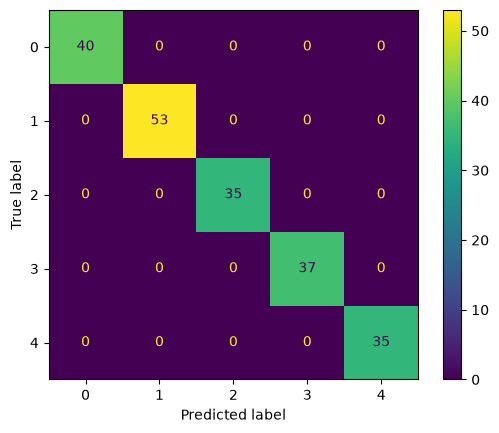

In [ ]:
#Confusion Matrix (Random Forest)
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

In [ ]:
#Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                    Feature  Importance
2              Speech_Error    0.812772
7       Pronunciation_Score    0.048793
0                       Age    0.035922
4         Sessions_Attended    0.033681
5  Practice_Minutes_Per_Day    0.029881
6            Parent_Support    0.014213
1                    Gender    0.010292
3                  Severity    0.008127
8               Improvement    0.006318


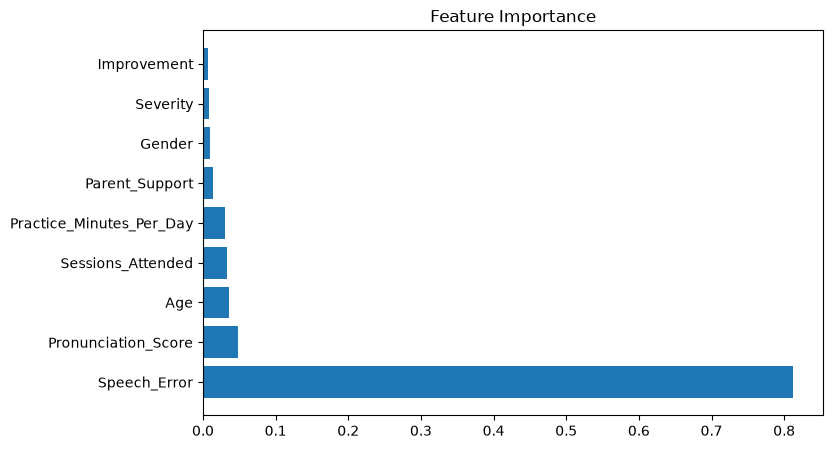

In [ ]:
#Feature Importance Graph
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.show()

In [ ]:
#Save Model
joblib.dump(
    rf,
    "speech_therapy_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
#Model Comparison
results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest","SVM"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred, average="weighted"),
        precision_score(y_test, dt_pred, average="weighted"),
        precision_score(y_test, rf_pred, average="weighted"),
        precision_score(y_test, svm_pred, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, lr_pred, average="weighted"),
        recall_score(y_test, dt_pred, average="weighted"),
        recall_score(y_test, rf_pred, average="weighted"),
        recall_score(y_test, svm_pred, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred, average="weighted"),
        f1_score(y_test, dt_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted"),
        f1_score(y_test, svm_pred, average="weighted")
    ]
})

results

In [ ]:
#Save Scaler and Target Encoder
joblib.dump(scaler, "scaler.pkl")
joblib.dump(target_encoder, "target_encoder.pkl")

In [ ]:
#Predict for a New Child
new_child = pd.DataFrame({
    "Age":[7],
    "Gender":[1],
    "Speech_Error":[2],
    "Severity":[1],
    "Sessions_Attended":[8],
    "Practice_Minutes_Per_Day":[20],
    "Parent_Support":[2],
    "Pronunciation_Score":[65],
    "Improvement":[1]
})

new_child = scaler.transform(new_child)

prediction = rf.predict(new_child)

exercise = target_encoder.inverse_transform(prediction)

print("Recommended Exercise:", exercise[0])